오퍼 수신/열람/완료 이벤트를 인스턴스 단위로 집계하여 'funnel_instance.csv' 생성


**경계 조건 및 설계 가정**
- 't_expire = t_received + duration * 24' (transcript.time: hour, portfolio.duration: day)
- 유효기간: 't_received <= event_time <= t_expire' (양 끝 포함, closed interval)
- ambiguous match: 복수 구간에 걸리면 가장 최근 수신 instance 선택
- 'is_aware = 1': 유효기간 내 조회 → 완료 순서 정상 ('t_viewed <= t_completed')
- 'is_aware_reliable = 1': is_aware + ambiguous_match = 0

## 1. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

# 한글 폰트
try:
    _font = next(
        (f for f in fm.findSystemFonts() if any(k in f for k in ["NanumGothic", "Malgun", "AppleGothic"])), None
    )
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font).get_name() if _font else "DejaVu Sans"
except Exception:
    plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 경로 설정
DATA_DIR = "../pjh_EDA/"
INPUT_FILE = DATA_DIR + "preprocessed_final.csv"
OUTPUT_FILE = DATA_DIR + "funnel_instance.csv"

# 스타벅스 컬러
COLORS = {
    "green": "#00704A",
    "gold": "#CBA258",
    "dark": "#1E3932",
    "light": "#D4E9E2",
}

print("환경 설정 완료")

환경 설정 완료


## 2. 데이터 로드 + 파생변수

In [2]:
full = pd.read_csv(INPUT_FILE)
print(f"full shape: {full.shape}")

# 날짜 파생변수
full["became_member_on"] = pd.to_datetime(full["became_member_on"], errors="coerce")
full["join_year"] = full["became_member_on"].dt.year
full["join_month"] = full["became_member_on"].dt.month
full["join_year_month"] = full["became_member_on"].dt.strftime("%Y-%m")
full["join_cohort"] = full["became_member_on"].dt.to_period("M")

# 고객 단위 기초 분포
customer_df = full.drop_duplicates("customer_id")
print(f"고객 수: {len(customer_df):,}명")
print("\n[ 가입 연도 분포 ]")
display(customer_df["join_year"].value_counts().sort_index())

print("[ 가입 월 분포 ]")
display(customer_df["join_month"].value_counts().sort_index())

print("[ Cohort 분포 ]")
display(customer_df["join_cohort"].value_counts().sort_index())

full shape: (306534, 29)
고객 수: 17,000명

[ 가입 연도 분포 ]


join_year
2013     286
2014     691
2015    1830
2016    3526
2017    6469
2018    4198
Name: count, dtype: int64

[ 가입 월 분포 ]


join_month
1     1525
2     1202
3     1329
4     1315
5     1307
6     1265
7     1359
8     1610
9     1515
10    1568
11    1449
12    1556
Name: count, dtype: int64

[ Cohort 분포 ]


join_cohort
2013-07      5
2013-08     68
2013-09     57
2013-10     56
2013-11     48
          ... 
2018-03    618
2018-04    585
2018-05    601
2018-06    562
2018-07    506
Freq: M, Name: count, Length: 61, dtype: int64

- events_df : offer viewed 또는 offer completed 이벤트만 필터링한 테이블
- event_time_col : 이벤트 시간 컬럼명 (t_viewed 또는 t_completed)
- recv_keys :  received 한 정보 모음
- _row_id : 이벤트 행을 식별자 (인덱스 개념) 
- valid : 시간 (t_received<=event_time_col<=t_expire) 필터링
- match_cnt : 각 오퍼 인스턴스가 몇 번 received 되었는가?
- match_count : 동일한 viewed 이벤트가 몇 번 수신 구간에 들어왔는지 카운트 
- ambiguous_match : 첫 오퍼를 받은 이후 아직 duration내에 또다른(같은 offer_id) 오퍼를 또 받았으니, 가장 최근 instance로 결정


## 최종 코드 흐름 정리
received / viewed / completed 분리

instance_id 부여 + t_expire 계산

interval_join -> view_map, comp_map

view_summary, comp_summary 집계

funnel_instance 생성 (received + view_summary + comp_summary)

gap 파생변수 계산

퍼널 플래그 (is_viewed, is_completed)

completed_without_prior_view + nan 처리

is_aware + is_aware_reliable  ← 추가 위치

퍼널 요약 출력

## 3. 이벤트 분리 + instance_id + t_expire

In [3]:
def _split_event(full: pd.DataFrame, event: str, time_col: str) -> pd.DataFrame:
    """full에서 특정 이벤트만 추출하고 time 컬럼을 rename"""
    return (
        full.loc[full["event"] == event, ["customer_id", "offer_id", "time", "offer_type"]]
        .rename(columns={"time": time_col})
        .sort_values(["customer_id", "offer_id", time_col])
        .reset_index(drop=True)
    )


received = _split_event(full, "offer received", "t_received")
viewed = _split_event(full, "offer viewed", "t_viewed")
completed = _split_event(full, "offer completed", "t_completed")


# instance_id: 같은 고객이 같은 오퍼를 여러 번 받을 때 회차 구분
received["instance_id"] = received.groupby(["customer_id", "offer_id"]).cumcount() + 1


# t_expire = t_received + duration * 24
# [경계조건] transcript.time: hour / portfolio.duration: day
# 양 끝 포함 (closed interval) — 수신 즉시 이벤트 발생 사례 존재
portfolio_dur = full[["offer_id", "duration"]].dropna(subset=["offer_id"]).drop_duplicates("offer_id")

received = received.merge(portfolio_dur, on="offer_id", how="left")
received["t_expire"] = received["t_received"] + received["duration"] * 24

recv_keys = received[["customer_id", "offer_id", "t_received", "instance_id", "t_expire"]]

print(f"received:  {len(received):,}행")
print(f"viewed:    {len(viewed):,}행")
print(f"completed: {len(completed):,}행")

received:  76,277행
viewed:    57,725행
completed: 33,579행


## 4. interval_join → view_map, comp_map

In [4]:
def interval_join(events_df: pd.DataFrame, event_time_col: str) -> pd.DataFrame:
    """
    이벤트를 수신 구간 [t_received, t_expire] 에 매핑.

    Parameters
    ----------
    events_df      : offer viewed 또는 offer completed 이벤트 테이블
    event_time_col : 이벤트 시간 컬럼명 (t_viewed | t_completed)

    Returns
    -------
    DataFrame  : 이벤트-인스턴스 매핑 결과
                 ambiguous_match=1: 복수 구간에 걸린 케이스
                 → 가장 최근 t_received 인스턴스 선택
    """
    df = events_df.copy()
    df["_row_id"] = range(len(df))  # 1행 → N행 팽창 추적용

    merged = df.merge(recv_keys, on=["customer_id", "offer_id"], how="left")

    # 유효기간 내 이벤트만 필터링
    valid = merged[
        (merged["t_received"] <= merged[event_time_col]) & (merged[event_time_col] <= merged["t_expire"])
    ].copy()

    # ambiguous: 같은 이벤트가 복수 구간에 걸린 건수 카운트
    match_cnt = valid.groupby("_row_id")["instance_id"].count().reset_index(name="match_count")
    valid = valid.merge(match_cnt, on="_row_id")
    valid["ambiguous_match"] = (valid["match_count"] > 1).astype(int)

    # ambiguous면 가장 최근 수신 instance 선택
    valid = (
        valid.sort_values("t_received", ascending=False)
        .drop_duplicates(subset="_row_id", keep="first")
        .drop(columns="_row_id")
    )
    return valid


view_map = interval_join(viewed, "t_viewed")
comp_map = interval_join(completed, "t_completed")

print(f'열람: 유효 구간 밖 {len(viewed)-len(view_map):,}건 / ambiguous {view_map["ambiguous_match"].sum():,}건')
print(f'완료: 유효 구간 밖 {len(completed)-len(comp_map):,}건 / ambiguous {comp_map["ambiguous_match"].sum():,}건')

열람: 유효 구간 밖 1,158건 / ambiguous 2,339건
완료: 유효 구간 밖 0건 / ambiguous 1,776건


In [5]:
view_map = view_map.sort_values(by=["customer_id", "offer_id"])
view_map

,customer_id,offer_id,t_viewed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,informational,336,1,432.0,1,0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,informational,168,1,240.0,1,0
2,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,456,bogo,408,1,528.0,1,0
3,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,540,discount,504,1,744.0,1,0
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,630,bogo,576,2,696.0,1,0
...,...,...,...,...,...,...,...,...,...
58929,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,582,discount,576,3,744.0,1,0
58928,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
58926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,354,discount,336,1,504.0,1,0
58930,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,534,bogo,504,1,672.0,1,0


In [6]:
comp_map = comp_map.sort_values(by=["customer_id", "offer_id"])
comp_map

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,576,1,744.0,1,0
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,bogo,408,1,528.0,1,0
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,discount,504,1,744.0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,576,discount,408,1,648.0,1,0
4,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,discount,168,1,336.0,1,0
...,...,...,...,...,...,...,...,...,...
35373,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,576,3,744.0,2,1
35371,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,discount,408,2,576.0,2,1
35369,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,discount,336,1,504.0,1,0
35374,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,504,1,672.0,1,0


In [7]:
dup_rows = comp_map[comp_map.duplicated(subset=["customer_id", "offer_id", "t_completed"], keep=False)]
dup_rows.sort_values(["customer_id", "offer_id", "t_completed"]).head(10)

,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
94,00d7c95f793a4212af44e632fdc1e431,2906b810c7d4411798c6938adc9daaa5,504,discount,504,2,672.0,2,1
96,00d7c95f793a4212af44e632fdc1e431,2906b810c7d4411798c6938adc9daaa5,504,discount,504,2,672.0,2,1
195,01925607d99c460996c281f17cdbb9e2,4d5c57ea9a6940dd891ad53e9dbe8da0,510,bogo,504,2,624.0,2,1
197,01925607d99c460996c281f17cdbb9e2,4d5c57ea9a6940dd891ad53e9dbe8da0,510,bogo,504,2,624.0,2,1
201,01956670cf414b309675aa73368b94a9,2906b810c7d4411798c6938adc9daaa5,420,discount,408,2,576.0,2,1
203,01956670cf414b309675aa73368b94a9,2906b810c7d4411798c6938adc9daaa5,420,discount,408,2,576.0,2,1
249,01ff6c5d8d014dbd8c120e2b43a065ea,9b98b8c7a33c4b65b9aebfe6a799e6d9,444,bogo,408,2,576.0,2,1
251,01ff6c5d8d014dbd8c120e2b43a065ea,9b98b8c7a33c4b65b9aebfe6a799e6d9,444,bogo,408,2,576.0,2,1
256,0200f61c69da4c2ea078842cdaf234e6,2906b810c7d4411798c6938adc9daaa5,450,discount,408,2,576.0,2,1
258,0200f61c69da4c2ea078842cdaf234e6,2906b810c7d4411798c6938adc9daaa5,450,discount,408,2,576.0,2,1


## 5. 품질 체크 1

In [8]:
# == [품질 체크 1] view_map / comp_map 원본 중복 확인 ==
# 같은 고객이 같은 시각에 같은 오퍼를 중복 매핑한 행 탐색
dup_view_map = view_map[view_map.duplicated(subset=["customer_id", "offer_id", "t_viewed"], keep=False)]
dup_comp_map = comp_map[comp_map.duplicated(subset=["customer_id", "offer_id", "t_completed"], keep=False)]

print(f"view_map 중복 행: {len(dup_view_map)}건")  # 중복 없음
print(f"comp_map 중복 행: {len(dup_comp_map)}건")  # 중복 존재

if len(dup_view_map) > 0:
    display(dup_view_map.sort_values(["customer_id", "offer_id", "t_viewed"]).head(10))
if len(dup_comp_map) > 0:
    display(dup_comp_map.sort_values(["customer_id", "offer_id", "t_completed"]).head(10))

view_map 중복 행: 0건
comp_map 중복 행: 793건


,customer_id,offer_id,t_completed,offer_type,t_received,instance_id,t_expire,match_count,ambiguous_match
94,00d7c95f793a4212af44e632fdc1e431,2906b810c7d4411798c6938adc9daaa5,504,discount,504,2,672.0,2,1
96,00d7c95f793a4212af44e632fdc1e431,2906b810c7d4411798c6938adc9daaa5,504,discount,504,2,672.0,2,1
195,01925607d99c460996c281f17cdbb9e2,4d5c57ea9a6940dd891ad53e9dbe8da0,510,bogo,504,2,624.0,2,1
197,01925607d99c460996c281f17cdbb9e2,4d5c57ea9a6940dd891ad53e9dbe8da0,510,bogo,504,2,624.0,2,1
201,01956670cf414b309675aa73368b94a9,2906b810c7d4411798c6938adc9daaa5,420,discount,408,2,576.0,2,1
203,01956670cf414b309675aa73368b94a9,2906b810c7d4411798c6938adc9daaa5,420,discount,408,2,576.0,2,1
249,01ff6c5d8d014dbd8c120e2b43a065ea,9b98b8c7a33c4b65b9aebfe6a799e6d9,444,bogo,408,2,576.0,2,1
251,01ff6c5d8d014dbd8c120e2b43a065ea,9b98b8c7a33c4b65b9aebfe6a799e6d9,444,bogo,408,2,576.0,2,1
256,0200f61c69da4c2ea078842cdaf234e6,2906b810c7d4411798c6938adc9daaa5,450,discount,408,2,576.0,2,1
258,0200f61c69da4c2ea078842cdaf234e6,2906b810c7d4411798c6938adc9daaa5,450,discount,408,2,576.0,2,1


In [9]:
# 인스턴스별 요약 집계
view_summary = view_map.groupby(["customer_id", "offer_id", "instance_id"], as_index=False).agg(
    first_viewed=("t_viewed", "min"),
    last_viewed=("t_viewed", "max"),
    view_count=("t_viewed", "count"),
    view_ambiguous=("ambiguous_match", "max"),
)
comp_summary = comp_map.groupby(["customer_id", "offer_id", "instance_id"], as_index=False).agg(
    first_completed=("t_completed", "min"),
    last_completed=("t_completed", "max"),
    complete_count=("t_completed", "count"),
    comp_ambiguous=("ambiguous_match", "max"),
)

# 탐색: 같은 인스턴스 내 완료 2회 이상 케이스
multi_comp = comp_summary[
    (comp_summary["complete_count"] > 1) & (comp_summary["first_completed"] != comp_summary["last_completed"])
]
print(f"완료 2회 이상 인스턴스: {len(multi_comp)}건")
if len(multi_comp) > 0:
    display(multi_comp.head())

완료 2회 이상 인스턴스: 81건


,customer_id,offer_id,instance_id,first_completed,last_completed,complete_count,comp_ambiguous
294,0246e7cc7a3d4a98a940cb13776b5b55,fafdcd668e3743c1bb461111dcafc2a4,2,582,624,2,1
505,041fd7c6b796430a867c4e03d2ff8f4d,0b1e1539f2cc45b7b9fa7c272da2e1d7,3,648,702,2,1
745,05e6bcb70fe14e0da4730527ca35a4ae,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,510,540,2,1
754,05f4d69f73024172a23a350e611166b4,0b1e1539f2cc45b7b9fa7c272da2e1d7,2,414,432,2,1
904,072290a7410e49d3a1e45a89c92c58f3,2298d6c36e964ae4a3e7e9706d1fb8c2,2,432,468,2,1


## | **품질체크2**

In [10]:
# ── [품질 체크 2] summary 단위 중복 + ambiguous 건수 ──────
dup_view = view_summary.duplicated(subset=["customer_id", "offer_id", "first_viewed"]).sum()
dup_comp = comp_summary.duplicated(subset=["customer_id", "offer_id", "first_completed"]).sum()

print(f"[중복 매핑] view_summary: {dup_view}건 / comp_summary: {dup_comp}건 (0이어야 정상)")
assert dup_view == 0, f"view_summary 중복 {dup_view}건"
assert dup_comp == 0, f"comp_summary 중복 {dup_comp}건"

# ambiguous: 복수 구간에 걸려 인스턴스 연결이 불확실한 케이스(tie-break: 최근 t_received 기준 1개 선택)
# 최근 수신 instance로 tie-break 처리했으나 신뢰도 낮음
# is_aware_reliable에서 해당 케이스 제외
ambig_v = view_summary["view_ambiguous"].sum()
ambig_c = comp_summary["comp_ambiguous"].sum()
print(f"[Ambiguous match] view: {ambig_v:,}건 / comp: {ambig_c:,}건 → 최근 수신 instance 선택")

print("✓ 품질 체크 2 통과")

[중복 매핑] view_summary: 0건 / comp_summary: 0건 (0이어야 정상)
[Ambiguous match] view: 2,339건 / comp: 1,328건 → 최근 수신 instance 선택
✓ 품질 체크 2 통과


## 6. funnel_instance 생성 + 파생변수 + 플래그

## | **instance 생성**

In [11]:
# 4. funnel_instance 생성
funnel_instance = received.merge(view_summary, on=["customer_id", "offer_id", "instance_id"], how="left").merge(
    comp_summary, on=["customer_id", "offer_id", "instance_id"], how="left"
)
assert len(funnel_instance) == len(received), "행 수 불일치 — merge 오류"

In [12]:
# 5. gap 파생변수 (first_ 컬럼명 기준)
funnel_instance["gap_to_first_view"] = funnel_instance["first_viewed"] - funnel_instance["t_received"]
funnel_instance["gap_to_first_complete"] = funnel_instance["first_completed"] - funnel_instance["t_received"]

# gap_view_to_complete: 조회 있음 & 완료 있음 & 시간 순서 정상인 경우만 계산
# strict < 사용 → 동시 발생은 역순으로 간주하지 않지만 완료가 먼저인 경우 nan
_mask_seq = (
    funnel_instance["first_viewed"].notna()
    & funnel_instance["first_completed"].notna()
    & (funnel_instance["first_viewed"] < funnel_instance["first_completed"])  # < 로 변경
)
funnel_instance["gap_first_view_to_first_complete"] = np.where(
    _mask_seq, funnel_instance["first_completed"] - funnel_instance["first_viewed"], np.nan
)

funnel_instance["gap_to_first_view_day"] = funnel_instance["gap_to_first_view"] / 24
funnel_instance["gap_to_first_complete_day"] = funnel_instance["gap_to_first_complete"] / 24
funnel_instance["gap_first_view_to_first_complete_day"] = funnel_instance["gap_first_view_to_first_complete"] / 24

In [13]:
# 6. 컬럼명 통일 (first_ → t_, gap_to_first_ → gap_to_)
funnel_instance = funnel_instance.rename(
    columns={
        "first_viewed": "t_viewed",
        "first_completed": "t_completed",
        "gap_to_first_view": "gap_to_view",
        "gap_to_first_complete": "gap_to_complete",
        "gap_first_view_to_first_complete": "gap_view_to_complete",
        "gap_to_first_view_day": "gap_to_view_day",
        "gap_to_first_complete_day": "gap_to_complete_day",
        "gap_first_view_to_first_complete_day": "gap_view_to_complete_day",
    }
)

print(f"funnel_instance shape: {funnel_instance.shape}")
print("컬럼:", list(funnel_instance.columns))

funnel_instance shape: (76277, 21)
컬럼: ['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id', 'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count', 'view_ambiguous', 't_completed', 'last_completed', 'complete_count', 'comp_ambiguous', 'gap_to_view', 'gap_to_complete', 'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day', 'gap_view_to_complete_day']


In [14]:
# 7. 퍼널 플래그 (rename 이후 컬럼명 기준)
funnel_instance["is_viewed"] = funnel_instance["t_viewed"].notna()
funnel_instance["is_completed"] = funnel_instance["t_completed"].notna()

# completed_without_prior_view: 조회없이 완료 or 완료 후 조회(gap<0)
funnel_instance["was_viewed"] = funnel_instance["t_viewed"].notna().astype(int)
funnel_instance["was_completed"] = funnel_instance["t_completed"].notna().astype(int)

# completed_without_prior_view: 조회 없이 완료
# (gap이 mask로 nan 처리되어 역순 케이스 별도 처리 불필요)
# 조건 1: 조회 없이 완료 (was_viewed == 0)
# 조건 2: 완료가 조회보다 먼저 발생 (역순) → 오퍼 인지 없이 완료로 간주
# 마케팅 관점: 두 경우 모두 오퍼 인지 효과 없음 → 12.9%
funnel_instance["completed_without_prior_view"] = (
    (funnel_instance["is_completed"] & ~funnel_instance["is_viewed"])
    | (funnel_instance["t_completed"] < funnel_instance["t_viewed"])  # 역순 포함
).astype(int)

# valid_view_sequence (조회 다음 완료 순서 정상)
funnel_instance["valid_view_sequence"] = (
    funnel_instance["t_viewed"].notna()
    & funnel_instance["t_completed"].notna()
    & (funnel_instance["t_viewed"] <= funnel_instance["t_completed"])
).astype(int)

### | **is_aware** 정의
조건
1. 유효기간 내 완료 (is_completed == True)
2. 유효기간 내 조회 (is_viewed == True)
3. 조회가 완료보다 먼저 발생 (t_viewed <= t_completed)

valid_view_sequence가 이미 1~3을 통합한 컬럼
1. is_viewed == True
2. is_completed == True
3. t_viewed <= t_completed
    + funnel_instance 자체가 within_duration 보장

- is_aware = valid_view_sequence (수학적 동치)
- completed_without_prior_view: 미조회 OR 역순 케이스 포함 (12.9%)
- is_aware_reliable: is_aware + ambiguous_match = 0


In [15]:
# is_aware: 오퍼를 인지하고 완료한 케이스
# = valid_view_sequence와 수학적으로 동치
funnel_instance["is_aware"] = funnel_instance["valid_view_sequence"].astype(int)

# is_aware_reliable: ambiguous 매핑 제외한 신뢰도 높은 케이스
funnel_instance["is_aware_reliable"] = (
    (funnel_instance["is_aware"] == 1)
    & (funnel_instance["comp_ambiguous"] == 0)
    & (funnel_instance["view_ambiguous"] == 0)
).astype(int)

print("퍼널 플래그 생성 완료")

퍼널 플래그 생성 완료


In [16]:
# ── [품질 체크 3] informational offer completed 여부 ──────
info_completed = funnel_instance[
    (funnel_instance["offer_type"] == "informational") & (funnel_instance["is_completed"] == True)
]
print(f"[Informational completed] {len(info_completed)}건 (0이어야 정상)")
assert len(info_completed) == 0, f"informational completed {len(info_completed)}건 존재"
print("✓ 품질 체크 3 통과")

[Informational completed] 0건 (0이어야 정상)
✓ 품질 체크 3 통과


## 7. 오퍼 속성 병합 + CSV 저장

In [17]:
# offer_type_port: 시각화에서 offer_type 참조용
offer_type_map = (
    full[["offer_id", "offer_type"]]
    .dropna(subset=["offer_id"])
    .drop_duplicates("offer_id")
    .rename(columns={"offer_type": "offer_type_port"})
)
funnel_instance = funnel_instance.merge(offer_type_map, on="offer_id", how="left")

# 완료 인스턴스 서브셋
completed_funnel_instance = funnel_instance[funnel_instance["is_completed"]].copy()

# CSV 저장 (모든 컬럼 추가 완료 후)
funnel_instance.to_csv(OUTPUT_FILE, index=False)
print(f"저장 완료: {OUTPUT_FILE}")
print(f"전체 인스턴스: {len(funnel_instance):,}건 / 완료: {len(completed_funnel_instance):,}건")
print(f"저장 컬럼 수: {funnel_instance.shape[1]}")

저장 완료: ../pjh_EDA/funnel_instance.csv
전체 인스턴스: 76,277건 / 완료: 33,101건
저장 컬럼 수: 30


In [18]:
# 요약
total = len(funnel_instance)
print(f"\n전체 오퍼 received 인스턴스 수: {total:,}건")

print("\n[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]")
v = funnel_instance["gap_to_view"].dropna()
print(f"  평균   : {v.mean():.1f}시간 ({v.mean()/24:.1f}일)")
print(f"  중앙값 : {v.median():.1f}시간 ({v.median()/24:.1f}일)")
print(f"  6시간 내 열람 : {(v <= 6).mean()*100:.1f}%")
print(f"  24시간 내 열람: {(v <= 24).mean()*100:.1f}%")
print(f"  48시간 내 열람: {(v <= 48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]")
c = funnel_instance["gap_to_complete"].dropna()
print(f"  평균   : {c.mean():.1f}시간 ({c.mean()/24:.1f}일)")
print(f"  중앙값 : {c.median():.1f}시간 ({c.median()/24:.1f}일)")
print(f"  1일 내 완료: {(c <= 24).mean()*100:.1f}%")
print(f"  3일 내 완료: {(c <= 72).mean()*100:.1f}%")
print(f"  7일 내 완료: {(c <= 168).mean()*100:.1f}%")

print("\n[ 퍼널 요약 ]")
print(f"  Viewed rate          : {funnel_instance['is_viewed'].mean()*100:.1f}%")
print(f"  Completed rate       : {funnel_instance['is_completed'].mean()*100:.1f}%")
print(f"  완료했지만 미열람     : {funnel_instance['completed_without_prior_view'].mean()*100:.1f}%")
print(f"  is_aware             : {funnel_instance['is_aware'].mean()*100:.1f}%")
print(f"  is_aware_reliable    : {funnel_instance['is_aware_reliable'].mean()*100:.1f}%")


전체 오퍼 received 인스턴스 수: 76,277건

[ 수신 → 첫 열람 시간 간격 (열람한 인스턴스만) ]
  평균   : 24.4시간 (1.0일)
  중앙값 : 12.0시간 (0.5일)
  6시간 내 열람 : 38.5%
  24시간 내 열람: 67.3%
  48시간 내 열람: 85.2%

[ 수신 → 첫 완료 시간 간격 (완료한 인스턴스만) ]
  평균   : 61.2시간 (2.5일)
  중앙값 : 48.0시간 (2.0일)
  1일 내 완료: 31.2%
  3일 내 완료: 66.8%
  7일 내 완료: 96.7%

[ 퍼널 요약 ]
  Viewed rate          : 74.2%
  Completed rate       : 43.4%
  완료했지만 미열람     : 12.9%
  is_aware             : 30.5%
  is_aware_reliable    : 28.9%


## 8. 고객/오퍼 속성 병합 (분석용 funnel 생성)

In [19]:
# validate='m:1': 오른쪽 테이블 unique 보장 → 행 증폭 방지
offer_attr = (
    full[["offer_id", "reward", "difficulty", "ch_web", "ch_email", "ch_mobile", "ch_social", "channel_count"]]
    .dropna(subset=["offer_id"])
    .drop_duplicates("offer_id")
)
cust_attr = full[
    ["customer_id", "gender", "age_group", "income_group", "join_year", "join_month", "join_cohort"]
].drop_duplicates("customer_id")

funnel = funnel_instance.copy()
funnel = funnel.merge(offer_attr, on="offer_id", how="left", validate="m:1")
funnel = funnel.merge(cust_attr, on="customer_id", how="left", validate="m:1")

print(f"병합 후 shape: {funnel.shape}  (행 수 불변 확인: {len(funnel) == len(funnel_instance)})")

# 분석 대상: bogo/discount, 누락 제거
funnel_clean = funnel[
    funnel["offer_type"].isin(["bogo", "discount"])
    & (funnel["income_group"] != "누락")
    & (funnel["age_group"] != "누락")
].copy()
print(f"funnel_clean (bogo/discount, 누락 제외): {len(funnel_clean):,}건")

병합 후 shape: (76277, 43)  (행 수 불변 확인: True)
funnel_clean (bogo/discount, 누락 제외): 53,201건


## 9. EDA — 기초 분포

In [20]:
# ── 퍼널 전환율 요약 ──────────────────────────────────────
total = len(funnel_instance)

metrics = {
    "Viewed rate": funnel_instance["is_viewed"].mean(),
    "Completed rate": funnel_instance["is_completed"].mean(),
    "Completed w/o view": funnel_instance["completed_without_prior_view"].mean(),
    "is_aware": funnel_instance["is_aware"].mean(),
    "is_aware_reliable": funnel_instance["is_aware_reliable"].mean(),
}

print(f"\n전체 오퍼 수신 인스턴스: {total:,}건")
print("\n[ 퍼널 전환율 ]")
for k, v in metrics.items():
    print(f"  {k:<25}: {v*100:.1f}%")

# ── gap 통계 ─────────────────────────────────────────────
print("\n[ 수신 → 첫 열람 ]")
v = funnel_instance["gap_to_view"].dropna()
print(f"  평균 {v.mean():.1f}h ({v.mean()/24:.1f}d)  중앙값 {v.median():.1f}h ({v.median()/24:.1f}d)")
print(f"  6h내 {(v<=6).mean()*100:.1f}%  24h내 {(v<=24).mean()*100:.1f}%  48h내 {(v<=48).mean()*100:.1f}%")

print("\n[ 수신 → 첫 완료 ]")
c = funnel_instance["gap_to_complete"].dropna()
print(f"  평균 {c.mean():.1f}h ({c.mean()/24:.1f}d)  중앙값 {c.median():.1f}h ({c.median()/24:.1f}d)")
print(f"  1d내 {(c<=24).mean()*100:.1f}%  3d내 {(c<=72).mean()*100:.1f}%  7d내 {(c<=168).mean()*100:.1f}%")


전체 오퍼 수신 인스턴스: 76,277건

[ 퍼널 전환율 ]
  Viewed rate              : 74.2%
  Completed rate           : 43.4%
  Completed w/o view       : 12.9%
  is_aware                 : 30.5%
  is_aware_reliable        : 28.9%

[ 수신 → 첫 열람 ]
  평균 24.4h (1.0d)  중앙값 12.0h (0.5d)
  6h내 38.5%  24h내 67.3%  48h내 85.2%

[ 수신 → 첫 완료 ]
  평균 61.2h (2.5d)  중앙값 48.0h (2.0d)
  1d내 31.2%  3d내 66.8%  7d내 96.7%


In [21]:
# ── 오퍼 유형별 전환율 ────────────────────────────────────
display(funnel_instance.groupby("offer_type")[["is_viewed", "is_completed", "is_aware"]].mean().round(3))

# ── 오퍼 유형별 반응 시간 ─────────────────────────────────
print("\n[ 오퍼 유형별 완료 소요 시간 (중앙값) ]")
for otype in ["bogo", "discount"]:
    df = completed_funnel_instance.loc[completed_funnel_instance["offer_type_port"] == otype, "gap_to_complete"]
    print(f"  {otype:<12} 평균 {df.mean()/24:.1f}d  중앙값 {df.median()/24:.1f}d  (n={len(df):,})")

,is_viewed,is_completed,is_aware
offer_type,,,
bogo,0.828,0.508,0.359
discount,0.700,0.576,0.404
informational,0.653,0.000,0.000



[ 오퍼 유형별 완료 소요 시간 (중앙값) ]
  bogo         평균 2.1d  중앙값 1.8d  (n=15,501)
  discount     평균 3.0d  중앙값 2.5d  (n=17,600)


In [22]:
# ── is_aware 수치 검증 ────────────────────────────────────
total = len(funnel_instance)
aware = funnel_instance["is_aware"].sum()
reliable = funnel_instance["is_aware_reliable"].sum()
valid_seq = funnel_instance["valid_view_sequence"].sum()

print(f"valid_view_sequence : {valid_seq:,}건 ({valid_seq/total*100:.1f}%)")
print(f"is_aware            : {aware:,}건 ({aware/total*100:.1f}%)")
print(f"is_aware_reliable   : {reliable:,}건 ({reliable/total*100:.1f}%)")
print(f"ambiguous 제외 건수  : {aware - reliable:,}건")

# is_aware == valid_view_sequence 검증
assert aware == valid_seq, f"is_aware({aware}) ≠ valid_view_sequence({valid_seq})"
print("✓ is_aware == valid_view_sequence 검증 통과")

valid_view_sequence : 23,267건 (30.5%)
is_aware            : 23,267건 (30.5%)
is_aware_reliable   : 22,078건 (28.9%)
ambiguous 제외 건수  : 1,189건
✓ is_aware == valid_view_sequence 검증 통과


In [23]:
# 확인
print("is_aware 분포:")
print(funnel_instance["is_aware"].value_counts())
print()
print("is_aware_reliable 분포 (ambiguous 제외):")
print(funnel_instance["is_aware_reliable"].value_counts())
print()

is_aware 분포:
is_aware
0    53010
1    23267
Name: count, dtype: int64

is_aware_reliable 분포 (ambiguous 제외):
is_aware_reliable
0    54199
1    22078
Name: count, dtype: int64



## 10. 시각화 — Time Flow Analysis

In [24]:
# 자연 거래 vs 오퍼 중 거래 분류
tx = (
    full[full["event"] == "transaction"][["customer_id", "time", "amount", "income_group", "age_group"]]
    .copy()
    .reset_index(drop=True)
)

recv_window = received[["customer_id", "t_received", "t_expire"]].copy()
tx_recv = tx.merge(recv_window, on="customer_id", how="left")
tx_recv["is_active"] = (tx_recv["t_received"] <= tx_recv["time"]) & (tx_recv["t_expire"] >= tx_recv["time"])

active_flag = (
    tx_recv.groupby(["customer_id", "time"])["is_active"]
    .any()
    .reset_index()
    .rename(columns={"is_active": "has_active_offer"})
)
tx = tx.merge(active_flag, on=["customer_id", "time"], how="left")
tx["has_active_offer"] = tx["has_active_offer"].fillna(False)
tx["is_natural"] = ~tx["has_active_offer"]

nact_tx = tx[tx["is_natural"]].copy()
act_tx = tx[~tx["is_natural"]].copy()

print(f"전체 거래: {len(tx):,}건")
print(f"자연 거래: {len(nact_tx):,}건 ({len(nact_tx)/len(tx)*100:.1f}%)")
print(f"오퍼 중:   {len(act_tx):,}건 ({len(act_tx)/len(tx)*100:.1f}%)")

전체 거래: 138,953건
자연 거래: 17,090건 (12.3%)
오퍼 중:   121,863건 (87.7%)


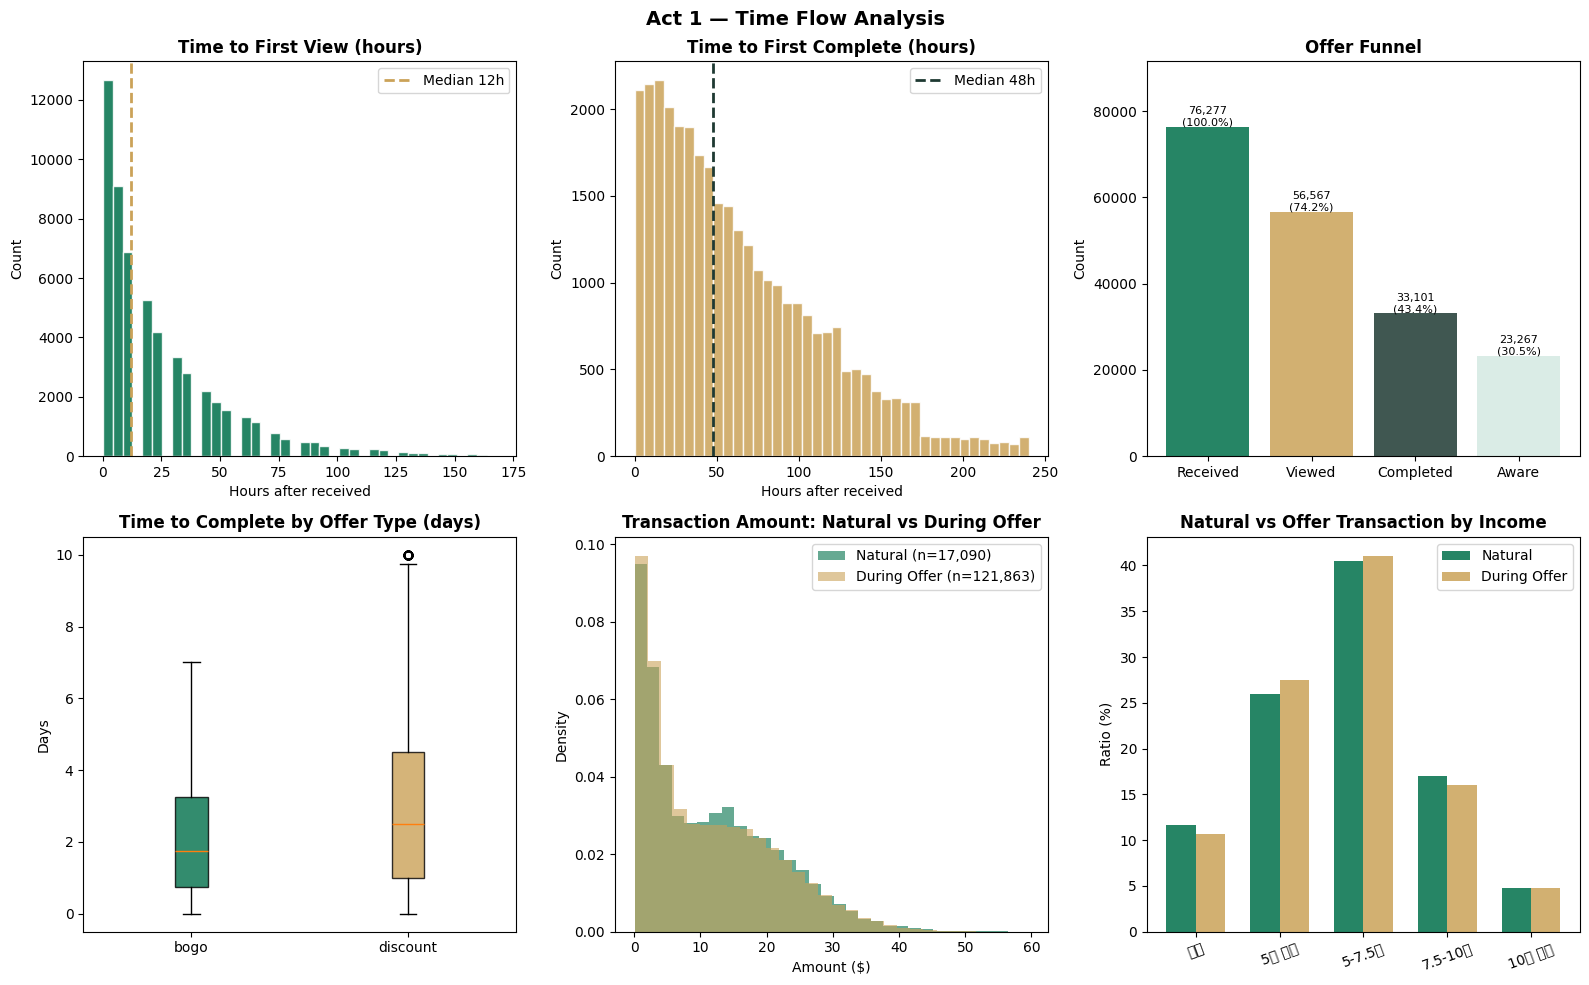

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Act 1 — Time Flow Analysis", fontsize=14, fontweight="bold")
green, gold, dark = COLORS["green"], COLORS["gold"], COLORS["dark"]

# 차트 1: 수신 → 첫 열람 시간 분포
ax = axes[0, 0]
v_plot = funnel_instance["gap_to_view"].dropna()
v_plot = v_plot[v_plot <= 168]
ax.hist(v_plot, bins=40, color=green, alpha=0.85, edgecolor="white")
ax.axvline(v_plot.median(), color=gold, linestyle="--", lw=2, label=f"Median {v_plot.median():.0f}h")
ax.set_title("Time to First View (hours)", fontweight="bold")
ax.set_xlabel("Hours after received")
ax.set_ylabel("Count")
ax.legend()

# 차트 2: 수신 → 첫 완료 시간 분포
ax = axes[0, 1]
c_plot = funnel_instance["gap_to_complete"].dropna()
c_plot = c_plot[c_plot <= 240]
ax.hist(c_plot, bins=40, color=gold, alpha=0.85, edgecolor="white")
ax.axvline(c_plot.median(), color=dark, linestyle="--", lw=2, label=f"Median {c_plot.median():.0f}h")
ax.set_title("Time to First Complete (hours)", fontweight="bold")
ax.set_xlabel("Hours after received")
ax.set_ylabel("Count")
ax.legend()

# 차트 3: 퍼널 단계별 수치
ax = axes[0, 2]
stages = ["Received", "Viewed", "Completed", "Aware"]
vals = [
    len(funnel_instance),
    funnel_instance["is_viewed"].sum(),
    funnel_instance["is_completed"].sum(),
    funnel_instance["is_aware"].sum(),
]
bars = ax.bar(stages, vals, color=[green, gold, dark, COLORS["light"]], alpha=0.85)
for bar, v in zip(bars, vals):
    pct = v / vals[0] * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300, f"{v:,}\n({pct:.1f}%)", ha="center", fontsize=8)
ax.set_title("Offer Funnel", fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(vals) * 1.2)

# 차트 4: 오퍼 유형별 반응 시간 박스플롯
ax = axes[1, 0]
box_data = [
    completed_funnel_instance.loc[completed_funnel_instance["offer_type_port"] == ot, "gap_to_complete"].dropna() / 24
    for ot in ["bogo", "discount"]
]
bp = ax.boxplot(box_data, labels=["bogo", "discount"], patch_artist=True)
for patch, c in zip(bp["boxes"], [green, gold]):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax.set_title("Time to Complete by Offer Type (days)", fontweight="bold")
ax.set_ylabel("Days")

# 차트 5: 자연 vs 오퍼 중 거래 금액
ax = axes[1, 1]
ax.hist(
    nact_tx.loc[nact_tx["amount"] <= 60, "amount"],
    bins=30,
    alpha=0.6,
    color=green,
    label=f"Natural (n={len(nact_tx):,})",
    density=True,
)
ax.hist(
    act_tx.loc[act_tx["amount"] <= 60, "amount"],
    bins=30,
    alpha=0.6,
    color=gold,
    label=f"During Offer (n={len(act_tx):,})",
    density=True,
)
ax.set_title("Transaction Amount: Natural vs During Offer", fontweight="bold")
ax.set_xlabel("Amount ($)")
ax.set_ylabel("Density")
ax.legend()

# 차트 6: 소득 구간 비교
ax = axes[1, 2]
inc_order = ["누락", "5만 미만", "5-7.5만", "7.5-10만", "10만 이상"]
nact_inc = nact_tx["income_group"].value_counts(normalize=True).reindex(inc_order, fill_value=0) * 100
act_inc = act_tx["income_group"].value_counts(normalize=True).reindex(inc_order, fill_value=0) * 100
x, w = range(len(inc_order)), 0.35
ax.bar([i - w / 2 for i in x], nact_inc.values, w, label="Natural", color=green, alpha=0.85)
ax.bar([i + w / 2 for i in x], act_inc.values, w, label="During Offer", color=gold, alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(inc_order, rotation=20)
ax.set_title("Natural vs Offer Transaction by Income", fontweight="bold")
ax.set_ylabel("Ratio (%)")
ax.legend()

plt.tight_layout()
plt.show()

In [26]:
first_viewed_instance = (  # 같은 오퍼를 여러번 받은 경우 이벤트를 '열람'한 오퍼
    funnel_instance[funnel_instance["is_viewed"]]
    .groupby(["customer_id", "offer_id"])["instance_id"]
    .min()
    .reset_index(name="first_viewed_instance")
)

In [27]:
first_viewed_instance["first_viewed_instance"].value_counts()
# => 같은 이벤트 3,4번째 보는 사람들은 안보는 경향 보임

first_viewed_instance
1    47024
2     1146
3       42
4        1
Name: count, dtype: int64

In [28]:
(first_viewed_instance["first_viewed_instance"].value_counts(normalize=True) * 100).round(2)

first_viewed_instance
1    97.53
2     2.38
3     0.09
4     0.00
Name: proportion, dtype: float64

In [29]:
funnel_instance.sort_values(by=["customer_id", "offer_id", "instance_id"])

,customer_id,offer_id,t_received,offer_type,instance_id,duration,t_expire,t_viewed,last_viewed,view_count,view_ambiguous,t_completed,last_completed,complete_count,comp_ambiguous,gap_to_view,gap_to_complete,gap_view_to_complete,gap_to_view_day,gap_to_complete_day,gap_view_to_complete_day,is_viewed,is_completed,was_viewed,was_completed,completed_without_prior_view,valid_view_sequence,is_aware,is_aware_reliable,offer_type_port
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,7.0,744.0,NaN,NaN,NaN,NaN,576.0,576.0,1.0,0.0,NaN,0.0,NaN,NaN,0.00,NaN,False,True,0,1,1,0,0,0,discount
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,4.0,432.0,372.0,372.0,1.0,0.0,NaN,NaN,NaN,NaN,36.0,NaN,NaN,1.50,NaN,NaN,True,False,1,0,0,0,0,0,informational
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,3.0,240.0,192.0,192.0,1.0,0.0,NaN,NaN,NaN,NaN,24.0,NaN,NaN,1.00,NaN,NaN,True,False,1,0,0,0,0,0,informational
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,5.0,528.0,456.0,456.0,1.0,0.0,414.0,414.0,1.0,0.0,48.0,6.0,NaN,2.00,0.25,NaN,True,True,1,1,1,0,0,0,bogo
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,10.0,744.0,540.0,540.0,1.0,0.0,528.0,528.0,1.0,0.0,36.0,24.0,NaN,1.50,1.00,NaN,True,True,1,1,1,0,0,0,discount
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,336,discount,1,7.0,504.0,354.0,354.0,1.0,0.0,384.0,384.0,1.0,0.0,18.0,48.0,30.0,0.75,2.00,1.25,True,True,1,1,0,1,1,1,discount
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,408,discount,2,7.0,576.0,414.0,414.0,1.0,1.0,414.0,414.0,1.0,1.0,6.0,6.0,NaN,0.25,0.25,NaN,True,True,1,1,0,1,1,0,discount
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,576,discount,3,7.0,744.0,582.0,582.0,1.0,0.0,576.0,576.0,1.0,1.0,6.0,0.0,NaN,0.25,0.00,NaN,True,True,1,1,1,0,0,0,discount
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,bogo,1,7.0,672.0,534.0,534.0,1.0,0.0,504.0,504.0,1.0,0.0,30.0,0.0,NaN,1.25,0.00,NaN,True,True,1,1,1,0,0,0,bogo


In [30]:
funnel_instance.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       'duration', 't_expire', 't_viewed', 'last_viewed', 'view_count',
       'view_ambiguous', 't_completed', 'last_completed', 'complete_count',
       'comp_ambiguous', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed', 'was_viewed',
       'was_completed', 'completed_without_prior_view', 'valid_view_sequence',
       'is_aware', 'is_aware_reliable', 'offer_type_port'],
      dtype='str')

In [31]:
funnel_instance[
    ["customer_id", "offer_id", "t_received", "offer_type", "instance_id", "is_viewed", "is_completed"]
].head()

,customer_id,offer_id,t_received,offer_type,instance_id,is_viewed,is_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,True,True


In [32]:
funnel_instance.groupby(["customer_id", "offer_id", "instance_id"])[["is_viewed", "is_completed"]].first().reset_index()

,customer_id,offer_id,instance_id,is_viewed,is_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,1,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,1,True,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,1,True,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1,True,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1,True,True
...,...,...,...,...,...
76272,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,1,True,True
76273,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,2,True,True
76274,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,3,True,True
76275,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,True,True


In [33]:
funnel_instance.groupby("customer_id")["instance_id"].apply(list).reset_index().head()

,customer_id,instance_id
0,0009655768c64bdeb2e877511632db8f,"[1, 1, 1, 1, 1]"
1,00116118485d4dfda04fdbaba9a87b5c,"[1, 2]"
2,0011e0d4e6b944f998e987f904e8c1e5,"[1, 1, 1, 1, 1]"
3,0020c2b971eb4e9188eac86d93036a77,"[1, 1, 1, 1, 2]"
4,0020ccbbb6d84e358d3414a3ff76cffd,"[1, 1, 1, 1]"


In [34]:
funnel_instance[funnel_instance["is_viewed"]].groupby("customer_id")["instance_id"].apply(list).reset_index()

,customer_id,instance_id
0,0009655768c64bdeb2e877511632db8f,"[1, 1, 1, 1]"
1,00116118485d4dfda04fdbaba9a87b5c,"[1, 2]"
2,0011e0d4e6b944f998e987f904e8c1e5,"[1, 1, 1, 1, 1]"
3,0020c2b971eb4e9188eac86d93036a77,"[1, 1]"
4,0020ccbbb6d84e358d3414a3ff76cffd,"[1, 1, 1, 1]"
...,...,...
16788,fff3ba4757bd42088c044ca26d73817a,"[2, 1, 1]"
16789,fff7576017104bcc8677a8d63322b5e1,"[1, 1, 1, 2]"
16790,fff8957ea8b240a6b5e634b6ee8eafcf,"[1, 1]"
16791,fffad4f4828548d1b5583907f2e9906b,"[1, 1, 1, 2]"


- 0009...  [1, 1, 1, 1, 1]  → 5개 오퍼를 받았고 모두 첫 번째 수신 (같은 오퍼를 두 번 받은 경우 없음)
- 00116... [1, 2]           → 같은 오퍼를 2번 받음 (instance_id 1, 2)
- 0020c... [1, 1, 1, 1, 2]  → 4개는 첫 수신, 1개는 같은 오퍼를 두 번째로 받음

In [35]:
print("received 원건수:", len(received))
print("instance funnel 원건수:", len(funnel_instance))

received 원건수: 76277
instance funnel 원건수: 76277


In [36]:
print("Viewed rate:", funnel_instance["is_viewed"].mean())  # 오퍼 노출은 잘 된다 (0.74)
print("Completed rate:", funnel_instance["is_completed"].mean())  # 전환에서 크게 떨어진다 (0.43)
print(
    "Completed without prior view:", (funnel_instance["completed_without_prior_view"]).mean()
)  # 사용자가 오퍼를 안 보고도 조건을 충족해서 reward를 받음

Viewed rate: 0.7415996958454055
Completed rate: 0.4339578116601335
Completed without prior view: 0.12892483972888288


In [37]:
print((funnel_instance["gap_to_view"] < 0).sum())
print((funnel_instance["gap_to_complete"] < 0).sum())
print((funnel_instance["gap_view_to_complete"] < 0).sum())
# completed < viewed
# 완료가 열람보다 먼저 발생 -> viewed 없이도 completion 가능

0
0
0


In [38]:
# 중복확인
funnel_instance[["customer_id", "offer_id", "instance_id"]].duplicated().sum()

np.int64(0)

In [39]:
funnel_instance.groupby("offer_type")[
    ["is_viewed", "is_completed", "gap_to_view", "gap_to_complete", "gap_view_to_complete"]
].mean()

,is_viewed,is_completed,gap_to_view,gap_to_complete,gap_view_to_complete
offer_type,,,,,
bogo,0.827896,0.508246,23.815842,49.562609,41.922873
discount,0.699669,0.576237,25.832007,71.402386,58.716480
informational,0.652904,0.000000,22.610837,NaN,NaN


In [40]:
funnel_instance.groupby("offer_type")["gap_to_complete"].median()

offer_type
bogo             42.0
discount         60.0
informational     NaN
Name: gap_to_complete, dtype: float64

# 발표에서 명시할 것
- 오퍼 인스턴스 단위로 is_aware 계산
- 유효기간(t_received ~ t_expire) 내 이벤트만 유효로 간주
- t_viewed <= t_completed 조건 만족 시 is_aware = 1
- ambiguous_match = 1인 케이스는 is_aware_reliable에서 제외